In [278]:
import numpy
import pandas

from matplotlib import pyplot
import seaborn

estres_empleados = pandas.read_csv(
    "../../conjuntos/estres.csv"
)

estres_empleados

,CARGA,SALARIO,ESTRES
0,10,18205.19,0.77
1,7,16133.27,0.13
2,8,15754.10,0.86
3,14,12583.51,2.05
4,9,14025.50,1.06
...,...,...,...
995,5,14347.02,0.48
996,13,21470.59,1.14
997,11,11801.91,1.04
998,14,21902.42,0.10


In [279]:
X = estres_empleados[["CARGA", "SALARIO"]].values

X

array([[1.000000e+01, 1.820519e+04],
       [7.000000e+00, 1.613327e+04],
       [8.000000e+00, 1.575410e+04],
       ...,
       [1.100000e+01, 1.180191e+04],
       [1.400000e+01, 2.190242e+04],
       [1.000000e+01, 1.273774e+04]])

In [280]:
y = estres_empleados["ESTRES"]

y

0      0.77
1      0.13
2      0.86
3      2.05
4      1.06
       ... 
995    0.48
996    1.14
997    1.04
998    0.10
999    1.16
Name: ESTRES, Length: 1000, dtype: float64

In [281]:
print("X", X.shape)
print("y", y.shape)

X (1000, 2)
y (1000,)


In [282]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=800
)

print("X_train", X_train.shape)
print("X_test", X_train.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (800, 2)
X_test (800, 2)
y_train (800,)
y_test (200,)


In [283]:
X_train

array([[1.200000e+01, 1.731366e+04],
       [9.000000e+00, 9.161820e+03],
       [1.100000e+01, 1.418901e+04],
       ...,
       [8.000000e+00, 1.932061e+04],
       [1.100000e+01, 1.168961e+04],
       [1.200000e+01, 8.740010e+03]])

In [284]:
Xd = numpy.array([
    numpy.zeros_like(X_train[:, 0]) + 1,
    X_train[:, 0],
    X_train[:, 1],
]).T

Xd

array([[1.000000e+00, 1.200000e+01, 1.731366e+04],
       [1.000000e+00, 9.000000e+00, 9.161820e+03],
       [1.000000e+00, 1.100000e+01, 1.418901e+04],
       ...,
       [1.000000e+00, 8.000000e+00, 1.932061e+04],
       [1.000000e+00, 1.100000e+01, 1.168961e+04],
       [1.000000e+00, 1.200000e+01, 8.740010e+03]])

In [285]:
betas = numpy.linalg.inv(
    Xd.T.dot(Xd)
).dot(
    Xd.T.dot(y_train)
)

betas

array([ 1.00717894e+00,  9.69904967e-02, -6.58239478e-05])

In [286]:
bias = betas[0]
b1 = betas[1]
b2 = betas[2]

print(f"bias = {bias}")
print(f"b1   = {b1}")
print(f"b2   = {b2}")

bias = 1.0071789418581023
b1   = 0.0969904966716586
b2   = -6.582394779824864e-05


In [287]:
import plotly.express as plotly

figure = plotly.scatter_3d(
    estres_empleados,
    x="CARGA",
    y="SALARIO",
    z="ESTRES",
    color="ESTRES"
)

figure.update_traces(
    marker=dict(
        size=1,
    )
)

figure.show()

In [288]:
import plotly.express as plotly

figure = plotly.scatter_3d(
    estres_empleados,
    x="CARGA",
    y="SALARIO",
    z="ESTRES",
    color="ESTRES"
)

figure.update_traces(
    marker=dict(
        size=1,
        color="gray",
        opacity=0.5
    )
)

figure.show()

In [289]:
import plotly.express as plotly

figure = plotly.scatter_3d(
    estres_empleados,
    x="CARGA",
    y="SALARIO",
    z="ESTRES",
    color="ESTRES"
)

figure.update_traces(
    marker=dict(
        size=2,
        #color="gray",
        opacity=1
    )
)

x1p = numpy.linspace(0, 20)
x2p = numpy.linspace(0, 30_000)

X1p, X2p = numpy.meshgrid(x1p, x2p)

yp = bias + X1p * b1 + X2p * b2

x1v = X1p.ravel()
x2v = X2p.ravel()

figure.add_trace(
    go.Scatter3d(
        x=x1v,
        y=x2v,
        z=yp.ravel(),
        mode="markers",
        marker=dict(
            size=2,
            color=yp.ravel(),
            colorscale="inferno",
            opacity=0.5
        ),
        name="Estrés"
    )
)

figure.show()

<Axes: >

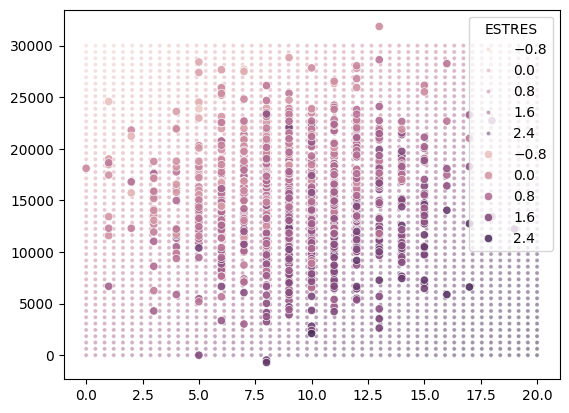

In [290]:
seaborn.scatterplot(
    x=x1v, 
    y=x2v, 
    hue=yp.ravel(), 
    alpha=0.5,
    marker="."
)
seaborn.scatterplot(
    x=X[:, 0], 
    y=X[:, 1], 
    hue=y, 
    alpha=0.9,
)

<Axes: >

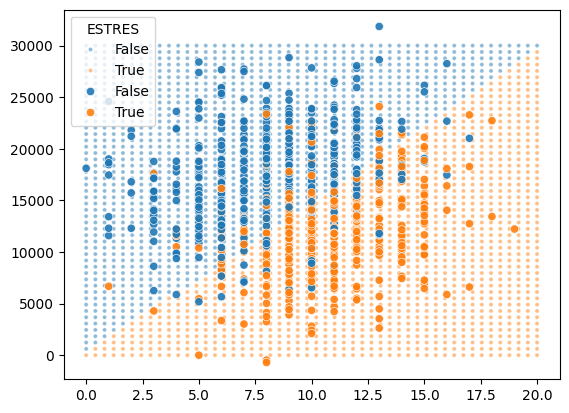

In [291]:
seaborn.scatterplot(
    x=x1v, 
    y=x2v, 
    hue=yp.ravel() >= 1, 
    alpha=0.5,
    marker="."
)
seaborn.scatterplot(
    x=X[:, 0], 
    y=X[:, 1], 
    hue=y >= 1, 
    alpha=0.9,
)

<Axes: >

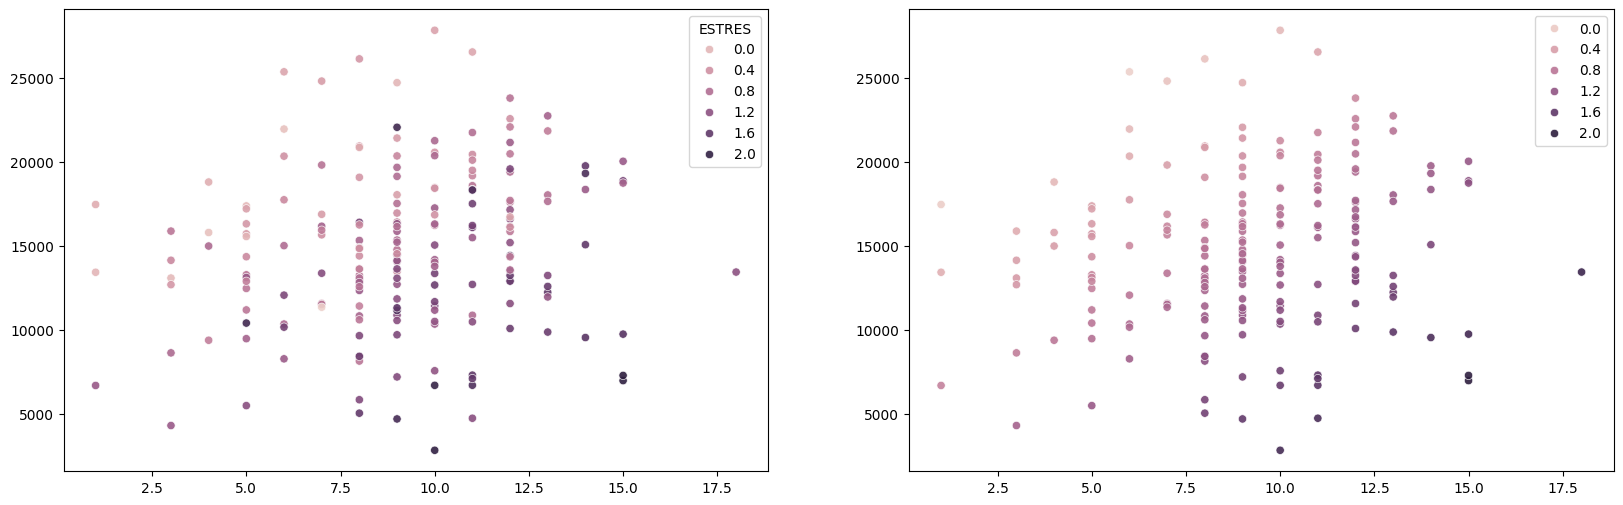

In [292]:
yp_test = bias + X_test[:, 0] * b1 + X_test[:, 1] * b2

figure, axis = pyplot.subplots(1, 2, figsize=(20, 6))

seaborn.scatterplot(
    x=X_test[:, 0], 
    y=X_test[:, 1], 
    hue=y_test, 
    alpha=0.9,
    ax=axis[0]
)
seaborn.scatterplot(
    x=X_test[:, 0], 
    y=X_test[:, 1], 
    hue=yp_test, 
    alpha=0.9,
    ax=axis[1]
)

<Axes: >

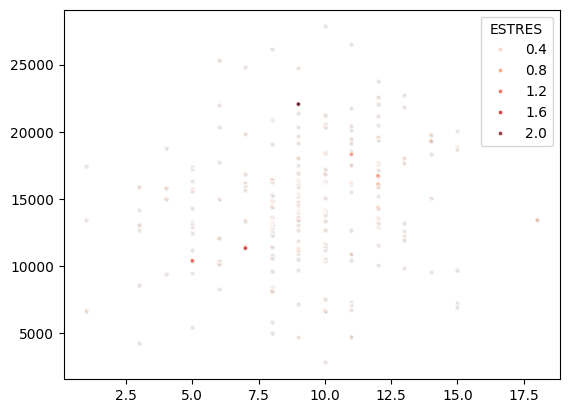

In [293]:
seaborn.scatterplot(
    x=X_test[:, 0], 
    y=X_test[:, 1], 
    alpha=0.8,
    color="gray",
    marker="."
)
seaborn.scatterplot(
    x=X_test[:, 0], 
    y=X_test[:, 1], 
    hue=(y_test - yp_test) ** 2, 
    alpha=0.8,
    palette="Reds",
    marker="."
)

<Axes: >

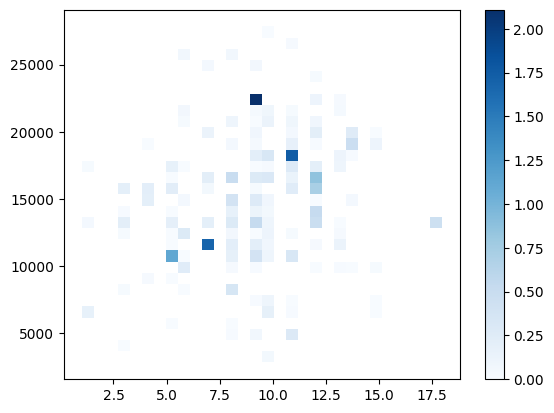

In [294]:
seaborn.histplot(
    x=X_test[:, 0],
    y=X_test[:, 1],
    weights=(y_test - yp_test) ** 2,
    bins=30,
    cbar=True,
    cmap="Blues"
)

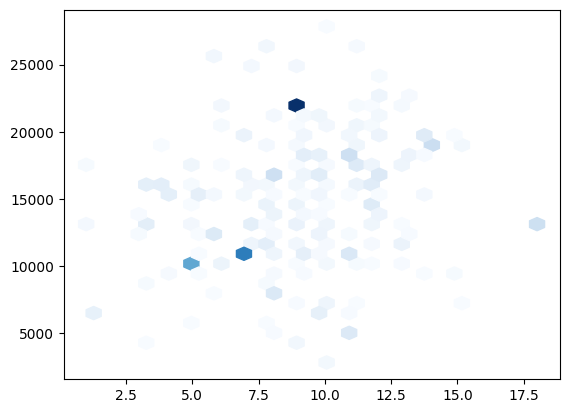

In [295]:
pyplot.hexbin(
    X_test[:, 0],
    X_test[:, 1],
    C=(y_test - yp_test) ** 2,
    reduce_C_function=numpy.mean,
    gridsize=30,
    cmap="Blues"
)

<Axes: >

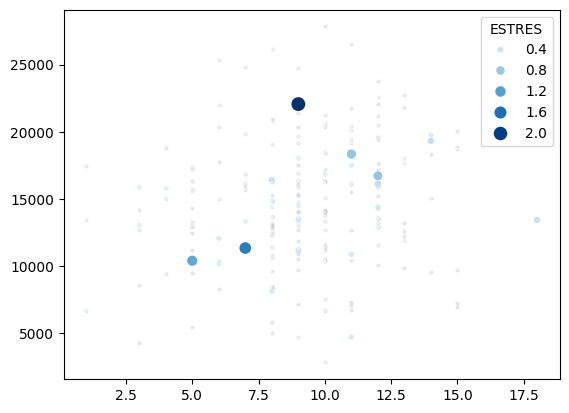

In [296]:
seaborn.scatterplot(
    x=X_test[:, 0], 
    y=X_test[:, 1], 
    alpha=0.2,
    color="gray",
    marker="."
)
seaborn.scatterplot(
    x=X_test[:, 0],
    y=X_test[:, 1],
    size=(y_test - yp_test) ** 2,
    hue=(y_test - yp_test) ** 2,
    palette="Blues",
    sizes=(0, 100),
    #legend=False,
)

In [297]:
import plotly.express as plotly

#figure = plotly.scatter_3d(
#    estres_empleados,
#    x="CARGA",
#    y="SALARIO",
#    z="ESTRES",
#    color="ESTRES"
#)
figure = plotly.scatter_3d(
    x=X_test[:, 0],
    y=X_test[:, 1],
    z=y_test,
    color=y_test
)

figure.update_traces(
    marker=dict(
        size=2,
        #color="gray",
        opacity=1
    )
)

x1p = numpy.linspace(0, 20)
x2p = numpy.linspace(0, 30_000)

X1p, X2p = numpy.meshgrid(x1p, x2p)

yp = bias + X1p * b1 + X2p * b2

x1v = X1p.ravel()
x2v = X2p.ravel()

figure.add_trace(
    go.Scatter3d(
        x=x1v,
        y=x2v,
        z=yp.ravel(),
        mode="markers",
        marker=dict(
            size=2,
            color=yp.ravel(),
            colorscale="inferno",
            opacity=0.5
        ),
        name="Estrés"
    )
)

xs = []
ys = []
zs = []

for x1, x2, yr, yp in zip(
    X_test[:, 0],
    X_test[:, 1],
    y_test,
    bias + X_test[:, 0] * b1 + X_test[:, 1] * b2
):
    xs.extend([x1, x1, None])
    ys.extend([x2, x2, None])
    zs.extend([yr, yp, None])

figure.add_trace(
    go.Scatter3d(
        x=xs,
        y=ys,
        z=zs,
        mode="lines",
        line=dict(width=1),
        name="Errores"
    )
)

figure.show()

In [298]:
import plotly.express as plotly

yp_test = bias + X_test[:, 0] * b1 + X_test[:, 1] * b2

figure = plotly.scatter_3d(
    x=X_test[:, 0],
    y=X_test[:, 1],
    z=y_test,
    color=(y_test - yp_test).abs(),
    color_continuous_scale="Reds"
)

figure.update_traces(
    marker=dict(
        size=2,
        #color="gray",
        opacity=1
    )
)

x1p = numpy.linspace(0, 20)
x2p = numpy.linspace(0, 30_000)

X1p, X2p = numpy.meshgrid(x1p, x2p)

yp = bias + X1p * b1 + X2p * b2

x1v = X1p.ravel()
x2v = X2p.ravel()

figure.add_trace(
    go.Scatter3d(
        x=x1v,
        y=x2v,
        z=yp.ravel(),
        mode="markers",
        marker=dict(
            size=3,
            color="white",
            #colorscale="inferno",
            opacity=0.5
        ),
        name="Estrés"
    )
)

xs = []
ys = []
zs = []

for x1, x2, yr, yp in zip(
    X_test[:, 0],
    X_test[:, 1],
    y_test,
    bias + X_test[:, 0] * b1 + X_test[:, 1] * b2
):
    xs.extend([x1, x1, None])
    ys.extend([x2, x2, None])
    zs.extend([yr, yp, None])

figure.add_trace(
    go.Scatter3d(
        x=xs,
        y=ys,
        z=zs,
        mode="lines",
        line=dict(width=1),
        name="Errores"
    )
)


figure.show()

In [299]:
import plotly.express as plotly

yp_test = bias + X_test[:, 0] * b1 + X_test[:, 1] * b2

figure = plotly.scatter_3d(
    x=X_test[:, 0],
    y=X_test[:, 1],
    z=y_test,
    color=(y_test - yp_test).abs(),
    color_continuous_scale="Reds"
)

figure.update_traces(
    marker=dict(
        size=2,
        #color="gray",
        opacity=1
    )
)

figure.show()

In [308]:
import plotly.express as plotly

yp = bias + X[:, 0] * b1 + X[:, 1] * b2

figure = plotly.scatter_3d(
    x=X[:, 0],
    y=X[:, 1],
    z=y,
    color=(y - yp).abs(),
    color_continuous_scale="inferno"
)

figure.update_traces(
    marker=dict(
        size=2,
        #color="gray",
        opacity=1
    )
)

figure.show()

In [310]:
import plotly.express as plotly

yp = bias + X[:, 0] * b1 + X[:, 1] * b2

figure = plotly.scatter_3d(
    x=X[:, 0],
    y=X[:, 1],
    z=y,
    color=(y - yp) ** 2,
    color_continuous_scale="inferno"
)

figure.update_traces(
    marker=dict(
        size=2,
        #color="gray",
        opacity=1
    )
)

figure.show()

In [316]:
import plotly.express as plotly

yp = bias + X[:, 0] * b1 + X[:, 1] * b2

figure = plotly.scatter_3d(
    x=X[:, 0],
    y=X[:, 1],
    z=y,
    color=(y - yp).abs() >= 0.3,
    color_continuous_scale="inferno"
)

figure.update_traces(
    marker=dict(
        size=2,
        #color="gray",
        opacity=1
    )
)

figure.show()

In [317]:
((y - yp).abs() >= 0.3).sum()

np.int64(322)

In [318]:
((y - yp).abs() >= 0.3).count()

np.int64(1000)

In [321]:
((y - yp).abs() >= 0.3).mean()

np.float64(0.322)

In [322]:
((y - yp).abs() < 0.3).mean()

np.float64(0.678)

In [326]:
(y_test - yp_test).abs().mean()

np.float64(0.25817661701718775)

In [327]:
((y_test - yp_test) ** 2).mean()

np.float64(0.11553776035008212)

In [328]:
((y_test - yp_test) ** 2).mean() ** 0.5

np.float64(0.339908458779834)

In [329]:
((y_test - yp_test).abs().mean() + ((y_test - yp_test) ** 2).mean() ** 0.5) / 2

np.float64(0.2990425378985109)

In [333]:
((y - yp).abs() <= 0.3).mean()

np.float64(0.678)

In [334]:
(y - yp).std()

np.float64(0.34750485867719905)

In [337]:
print("SSE:", ((y_test - yp_test) ** 2).sum())
print("MSE:", ((y_test - yp_test) ** 2).mean())
print("-" * 40)
print("MIN", (y - yp).abs().min())
print("MAE:", (y_test - yp_test).abs().mean())
print("MAX", (y - yp).abs().max())
print("RMSE:", ((y_test - yp_test) ** 2).mean() ** 0.5)
print("(MAE + RMSE)/2:", ((y_test - yp_test).abs().mean() + ((y_test - yp_test) ** 2).mean() ** 0.5) / 2)
print("RMSE/MAE:", ((y_test - yp_test) ** 2).mean() ** 0.5 / (y_test - yp_test).abs().mean())
print("-" * 40)
print("< 0.3:", ((y - yp).abs() <= 0.3).mean())
print("< 0.6:", ((y - yp).abs() <= 0.6).mean())
print("< 0.9:", ((y - yp).abs() <= 0.9).mean())
print("< 1.2:", ((y - yp).abs() <= 1.2).mean())
print("< 0.6:", ((y - yp).abs() <= 0.6).mean())
print("< 0.9:", ((y - yp).abs() <= 0.9).mean())
print("< 1.2:", ((y - yp).abs() <= 1.2).mean())

SSE: 23.107552070016425
MSE: 0.11553776035008212
----------------------------------------
MIN 0.000397748014032695
MAE: 0.25817661701718775
MAX 1.5194472929406821
RMSE: 0.339908458779834
(MAE + RMSE)/2: 0.2990425378985109
RMSE/MAE: 1.3165733702258755
----------------------------------------
< 0.3: 0.678
< 0.6: 0.911
< 0.9: 0.978
< 1.2: 0.992
< 0.6: 0.911
< 0.9: 0.978
< 1.2: 0.992


Text(0, 0.5, 'Cobertura')

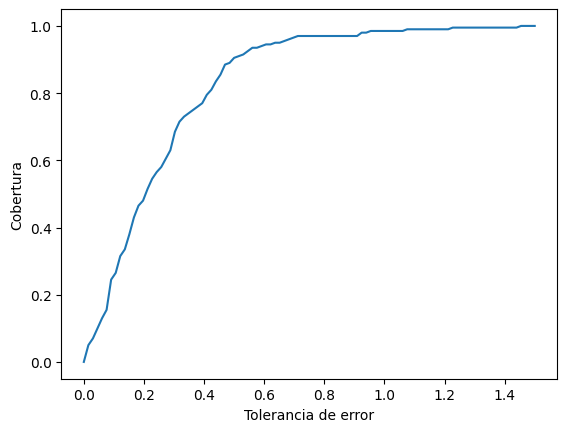

In [338]:
umbrales = numpy.linspace(0, 1.5, 100)

cobertura = [
    ((y_test - yp_test).abs() <= t).mean()
    for t in umbrales
]

pyplot.plot(umbrales, cobertura)
pyplot.xlabel("Tolerancia de error")
pyplot.ylabel("Cobertura")